In [1]:
import numpy as np
from POSEIDON.core import create_star, create_planet, load_data, wl_grid_constant_R, define_model, read_opacities, make_atmosphere, set_priors
from POSEIDON.constants import R_Sun, R_J
from POSEIDON.utility import read_retrieved_spectrum, plot_collection
from POSEIDON.visuals import plot_spectra_retrieved, plot_data
from POSEIDON.corner import generate_cornerplot, generate_overplot
from POSEIDON.retrieval import run_retrieval

In [2]:
# Define stellar properties 
R_s = 0.687*R_Sun       # Stellar radius [m]
T_s = 4250.0            # Stellar effective temperature [K]
err_T_s = 70            # Stellar effective temperature error [K]
Met_s = 0.2             # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)]
log_g_s = 4.60          # Stellar log surface gravity [log10(cm/s^20)]

star = create_star(R_s, T_s, log_g_s, Met_s, T_eff_error = err_T_s)


# Define planetary properties 
planet_name = 'TOI-1130b'
R_p = 0.327*R_J         # Planetary radius [m]
# g_p = 14.4825           # Surface gravity [m/s^2]
log_g_p = 3.1609        # Log surface gravity [log10(g / cm/s^2)]  
T_eq = 825.0            # Equilibrium temperature [K]

planet = create_planet(planet_name, R_p, log_g = log_g_p, T_eq = T_eq)

In [4]:
# Define wavelength grid
wl_min = 0.6            # Min and max wavelengths
wl_max = 5.2           
R = 10000               # Spectral resolution of grid

wl = wl_grid_constant_R(wl_min, wl_max, R)

# Define data points
data_dir = '/home/peng/POSEIDON/POSEIDON/reference_data/observations/TOI-1130b'
datasets = ['TOI-1130b_Order2.dat', 'TOI-1130b_Order1.dat', 'TOI-1130b_NRS1.dat', 'TOI-1130b_NRS2.dat']
instruments = ['JWST_NIRISS_SOSS_Ord2', 'JWST_NIRISS_SOSS_Ord1', 'JWST_NIRSpec_G395H_NRS1', 'JWST_NIRSpec_G395H_NRS2']

data = load_data(data_dir, datasets, instruments, wl, 
                 offset_1_datasets = ['TOI-1130b_Order2.dat'], offset_2_datasets = ['TOI-1130b_Order1.dat'], offset_3_datasets = ['TOI-1130b_NRS2.dat'])

In [5]:
# Define models from completed retrievals
model_name_1 = 'water_only'
model_name_2 = 'add_stuff'
model_name_3 = 'no_offset'

bulk_species = ['H2', 'He']

param_species_1 = ['H2O']
param_species_2 = ['H2O', 'SO2', 'CO2', 'CH4']

model_1 = define_model(model_name_1, bulk_species, param_species_1, PT_profile = 'isotherm', X_profile = 'isochem', offsets_applied = 'three_datasets')
model_2 = define_model(model_name_2, bulk_species, param_species_2, PT_profile = 'isotherm', X_profile = 'isochem', offsets_applied = 'three_datasets')
model_3 = define_model(model_name_3, bulk_species, param_species_2, PT_profile = 'isotherm', X_profile = 'isochem')

# Check free params
print("Free parameters for model 1: " + str(model_1['param_names']))
print("Free parameters for model 2: " + str(model_2['param_names']))
print("Free parameters for model 3: " + str(model_3['param_names']))

Free parameters for model 1: ['R_p_ref' 'T' 'log_H2O' 'delta_rel_1' 'delta_rel_2' 'delta_rel_3']
Free parameters for model 2: ['R_p_ref' 'T' 'log_H2O' 'log_SO2' 'log_CO2' 'log_CH4' 'delta_rel_1'
 'delta_rel_2' 'delta_rel_3']
Free parameters for model 3: ['R_p_ref' 'T' 'log_H2O' 'log_SO2' 'log_CO2' 'log_CH4']


In [6]:
def plot_n_retrievals(star, planet, data, m_list, plot_name, dc_list, c_list):
    """ Given a list of models, make an overplot of all retrievals
    Args:
        star: Star dict from POSEIDON.core
        planet: Planet dict from POSEIDON.core
        data: load_data dict from POSEIDON.core
        m_list (list: str): List of models to plot, making sure that the first model has data offsets
        plot_name (str): Plot subtitle
        dc_list (list: str): List of colours for data points
        c_list (list: str): List of colours for each model
    Returns: None
    """
    pn = planet['planet_name']

    d_list = data['datasets']
    model_names = [m_list[i]['model_name'] for i in range(len(m_list))]
    
    for i in range(len(m_list)):
        if i == 0:
            wl, spec_low2, spec_low1, spec_median, spec_high1, spec_high2 = read_retrieved_spectrum(pn, model_names[0])
    
            spectra_median = plot_collection(spec_median, wl, collection = [])
            spectra_low1 = plot_collection(spec_low1, wl, collection = [])
            spectra_low2 = plot_collection(spec_low2, wl, collection = [])
            spectra_high1 = plot_collection(spec_high1, wl, collection = [])
            spectra_high2 = plot_collection(spec_high2, wl, collection = [])

        else: 
            wl, spec_low2, spec_low1, spec_median, spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_names[i])
            spectra_median = plot_collection(spec_median, wl, collection = spectra_median)
            spectra_low1 = plot_collection(spec_low1, wl, collection = spectra_low1)
            spectra_low2 = plot_collection(spec_low2, wl, collection = spectra_low2)
            spectra_high1 = plot_collection(spec_high1, wl, collection = spectra_high1)
            spectra_high2 = plot_collection(spec_high2, wl, collection = spectra_high2)

    fig_spec = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1, spectra_high1, spectra_high2, 
                                     pn, data, R_to_bin = 100, show_ymodel = False, plt_label = plot_name, data_labels = d_list, 
                                     data_colour_list = dc_list, spectra_labels = model_names, colour_list = c_list,
                                     add_retrieved_offsets = True, model = m_list[0])

    return None

[0] [11]
[11] [51]
[76] [116]
Applied 13.61 ppm offset to offset_1_datasets
Applied 11.26 ppm offset to offset_2_datasets
Applied -39.24 ppm offset to offset_3_datasets


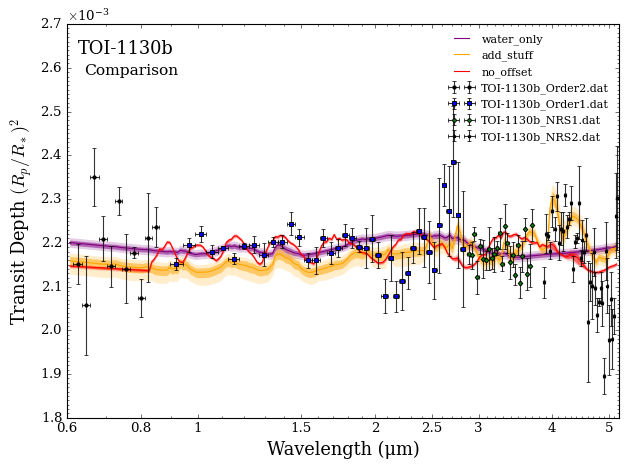

In [8]:
models = [model_1, model_2, model_3]
plot_n_retrievals(star, planet, data, models, 'Comparison', ['k', 'b', 'g', 'k'], ['purple', 'orange', 'red']) 